# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

## **Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

    - **General Linear Moddels:** A flexible version of standard regression that work even when your data doesn't follow a perfect bell curve. While normal linear models expect a straight line, GLMs use a special link to connect your inputs to different types of results, like yes/no outcomes or counts. Their main advantage is that they don't break down when your data is lopsided or restricted to specific ranges.
    - **Latent Variable Models:** Tools used to uncover hidden factors that you can't measure directly but know are influencing your results. For example, you can't measure intelligence or quality with a single ruler, so these models look at several related measurements to find the invisible pattern connecting them. Their big advantage is that they simplify complex data by focusing on these core, underlying themes rather than getting lost in the noise of individual measurements.
    - **Activation Functions:** In a computer model, they act like a gate that decides if a piece of information is important enough to pass through. Without these gates, the model would be stuck thinking in boring, straight lines and couldn't handle the complex curves found in real-world patterns. Their advantage is that they allow the model to learn sophisticated relationships, such as recognizing a face or predicting a chemical reaction, by turning simple inputs into complex decisions.

2. Explain why binary and categorical cross-entropy are effective loss functions for fitting logistic regression models.

    - Binary and categorical cross-entropy are effective because they use logarithms to harshly penalize incorrect guesses. When a model is very confident about the wrong answer, the "loss" value shoots toward infinity, forcing the model to make a major correction. Unlike a simple average of errors, these functions prioritize high accuracy for labels, ensuring the model's predicted probabilities align as closely as possible with the actual categories.

3. True or false, and explain: Logistic regression is a linear model.

    - False, because the relationship between your inputs and the predicted probability is an S-shaped curve, rather than a constant straight line. In a traditional linear model, a one-unit change in an input always results in the same fixed change in the output, but in logistic regression, that change depends on where you are on the curve. This curved link function is necessary to keep probabilities between 0 and 1, making the final model behavior fundamentally non-linear.

4. True or false, and explain: Logistic regression cannot be used for classification.

    - False, because classification is actually the primary purpose and most common use for logistic regression. While the model technically calculates a continuous probability between 0 and 1, we use that probability to "classify" data points into specific groups based on a chosen threshold. By deciding that any result above 0.5 belongs to one category and anything below belongs to another, we transform the mathematical prediction into a definitive classification tool.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

    - No, because the coefficient does not represent a direct change in the predicted probability, but rather the change in the log-odds of the outcome. In a standard linear model, a one-unit increase in a variable adds a fixed amount to the result, but in logistic regression, that same increase has a different impact on the final probability depending on where you start on the curve. To find the actual change in real-world terms, you usually have to transform the coefficient to see how the odds ratio changes.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

    - False, because while logistic regression uses a curved sigmoid function to output probabilities, it still relies on a linear combination of your inputs to draw its decision boundary. This means the model can only separate groups using a straight line; it cannot automatically see interactions between variables or handle complex, wiggly relationships on its own. To capture these more intricate patterns, you must use feature engineering—like squaring a variable or combining two features—to manually provide the model with the complexity it needs to improve its accuracy.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

    - False, because logistic regression and ordinary least squares (OLS) are designed for two completely different types of problems. Logistic regression is the right tool for classification when your outcome is a category, but OLS is far superior for regression when you are trying to predict a continuous number. You should choose the model based on the nature of the data you are predicting rather than assuming one is a universal upgrade over the other.


## **Necessary Data**

In [15]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


## **Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


### Question 2 - Part 1

In [16]:
import pandas as pd

df = pd.read_csv('data.csv', sep=';')

keep_cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]

df = df[keep_cols]

display(df.head())


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


Confirms only the variables that will be used are kept.

In [17]:
df.isnull().sum()

,0
Debtor,0
Tuition fees up to date,0
Scholarship holder,0
Age at enrollment,0
Curricular units 1st sem (approved),0
Target,0


Confirms there are no missing values which need to be taken care of.

In [18]:
df['Binary_Target'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

display(df[['Target', 'Binary_Target']].head(17))

,Target,Binary_Target
0,Dropout,1
1,Graduate,0
2,Dropout,1
3,Graduate,0
4,Graduate,0
5,Graduate,0
6,Graduate,0
7,Dropout,1
8,Graduate,0
9,Dropout,1


Confirms a new binary variables has been created, where Dropout is 1 and Graduate and Enrolled are 0.

### Question 2 - Part 2

In [19]:
import pandas as pd
from sklearn.linear_model import LogisticRegression


X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['Binary_Target']

model = LogisticRegression(penalty=None)
model.fit(X, y)

results = pd.DataFrame({'Variable': X.columns, 'Coefficient': model.coef_[0]})
display(results)

,Variable,Coefficient
0,Debtor,0.527137
1,Tuition fees up to date,-2.605617
2,Scholarship holder,-1.242299
3,Age at enrollment,0.049841


  - Having Tuition fees up to date and being a scholarhsip holder both decrease dropout probability, with tuition being the stronger indicator. On the other side, as age increases the probabiltiy also very slightly increase. Also, having debt largely increasing the probability of dropping out.
  - Yes, being up to date on tuition does seem to reduce dropout risk, being the strongest indicator of low dropout probability.

### Question 2 - Part 3

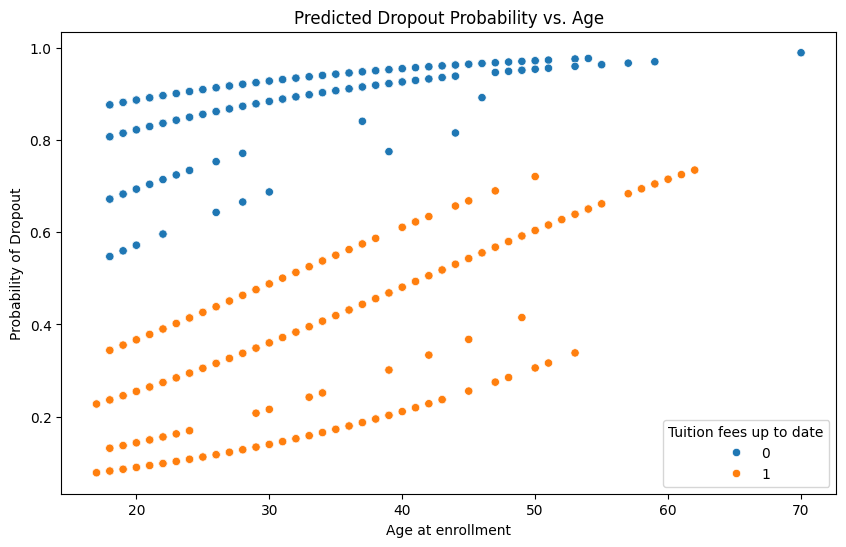

Average change in probability: -0.5233


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df['probs'] = model.predict_proba(X)[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age at enrollment', y='probs', hue='Tuition fees up to date')
plt.title('Predicted Dropout Probability vs. Age')
plt.ylabel('Probability of Dropout')
plt.show()


X_up_to_date = X.copy()
X_up_to_date['Tuition fees up to date'] = 1
probs_paid = model.predict_proba(X_up_to_date)[:, 1]

X_behind = X.copy()
X_behind['Tuition fees up to date'] = 0
probs_behind = model.predict_proba(X_behind)[:, 1]

avg_diff = (probs_paid - probs_behind).mean()
print(f"Average change in probability: {avg_diff:.4f}")

  - Being up to date on tuition reduces dropout probability the most for younger students (roughly ages 18 to 35). While the "Not up to date" group (blue) starts at a much higher risk even at young ages, the "Up to date" group (orange) starts very low, creating the largest vertical gap in probability at the left side of the plot. As age increases, the probabilities for both groups trend upward toward the 1.0 ceiling, which slightly compresses the difference between the two categories.
  - On average, being up to date on tuition reduces the predicted probability of dropout by 0.5233 (or 52.33%). This is shown by the value of -0.5233 below the graph.This is found by calculating the mean difference between the predicted probabilities for the entire dataset under two scenarios: one where every student is up to date on tuition and one where no one is.

### Question 2 - Part 4

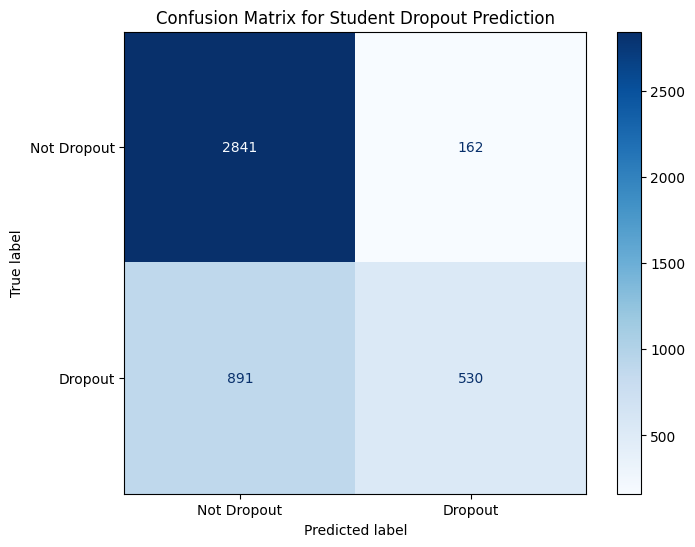


Accuracy: 0.7620


In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay


df['preds'] = model.predict(X)

conf_matrix = confusion_matrix(df['Binary_Target'], df['preds'])
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=['Not Dropout', 'Dropout'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix for Student Dropout Prediction')
plt.show()

accuracy = accuracy_score(df['Binary_Target'], df['preds'])
print(f"\nAccuracy: {accuracy:.4f}")

This model is 76.2% accurate, which doesn't feel very good given random guessing would be 50%. The model seems to predict "Not Dropout" far more heavily, leaving the bottom right square (correct dropout predictions) very weak.

### Question 2 - Part 5

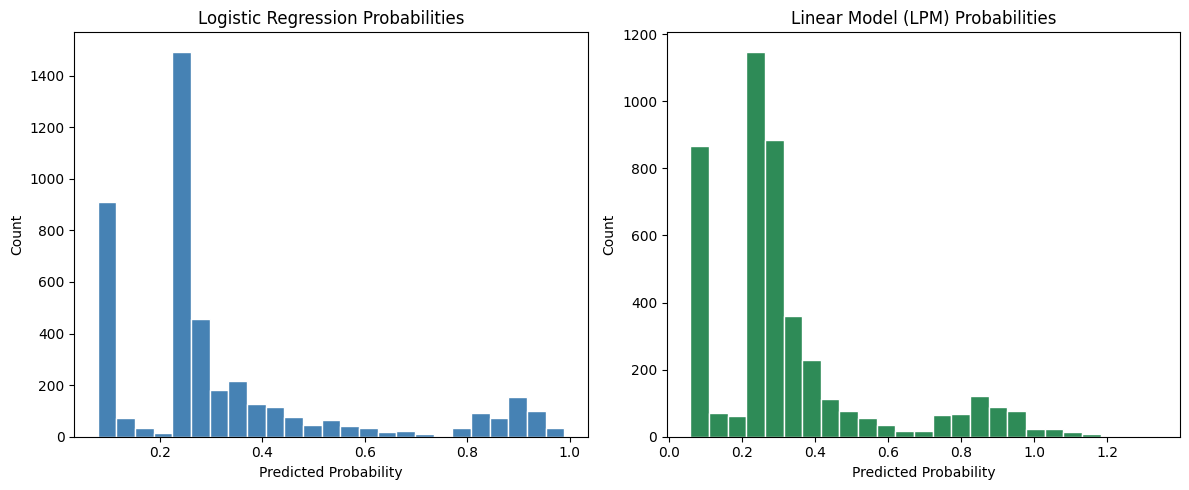

Logistic Regression Accuracy: 0.7620
Linear Model Accuracy: 0.7633


In [22]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['Binary_Target']

logit_probs = model.predict_proba(X)[:, 1]

lin_model = LinearRegression()
lin_model.fit(X, y)
lin_probs = lin_model.predict(X)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(logit_probs, bins=25, color='steelblue', edgecolor='white')
plt.title('Logistic Regression Probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(lin_probs, bins=25, color='seagreen', edgecolor='white')
plt.title('Linear Model (LPM) Probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

lin_preds = (lin_probs > 0.5).astype(int)
logit_preds = model.predict(X)

print(f"Logistic Regression Accuracy: {accuracy_score(y, logit_preds):.4f}")
print(f"Linear Model Accuracy: {accuracy_score(y, lin_preds):.4f}")

These two models ended up performing neearly identically, with the logistic regression having an accuracy of 76.2% and the linear regression having an accuracy of 76.33%. The histrograms do show that the linear regression does go out of the bounds of 0-1, but to a small degree that doesn't change much. Other than that, the histograms are extremely similar.

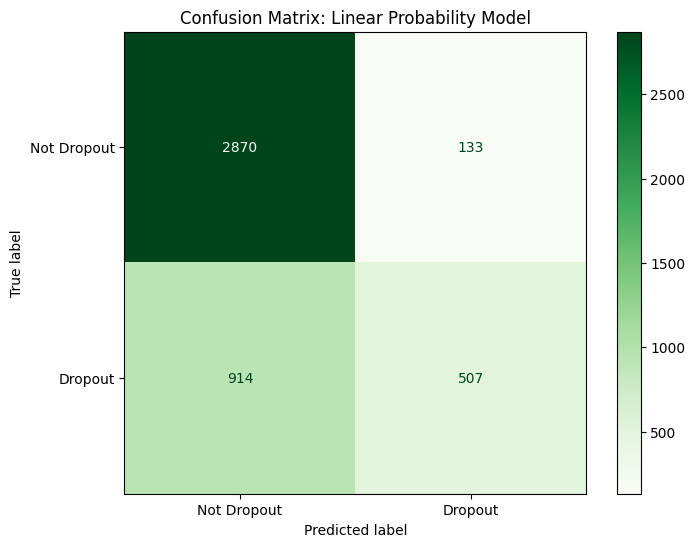

In [23]:
lin_conf_matrix = confusion_matrix(y, lin_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=lin_conf_matrix,
                              display_labels=['Not Dropout', 'Dropout'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Greens', ax=ax) # Using Green to match your LPM histogram
plt.title('Confusion Matrix: Linear Probability Model')
plt.show()

It seems that the linear model is more inclined to pick "Not Dropout", due to there being far fewer dropouts. This might indicate that the linear model isn't as "smart" as the logistic model, but simply favors picking the more popular option. This works when there is a lot of imbalance, such as in this data set, but would likely be exposed and perform worse than the logistic regression if the two classifications had more similar numbers.

### Question 2 - Part 6

  - Financial Distress (The Highest Indicator): Students who are not up to date on tuition fees and are classified as Debtors. As seen in the analysis, being behind on tuition increases the probability of dropout by a staggering average of 52%.
    - Since tuition status is the #1 predictor, the university could implement a grace period or emergency grants for students who fall behind. A small intervention here could result in a massive (52%) swing in their probability of staying.
  - Non-Scholarship Holders: Students without scholarship support have a significantly higher baseline risk (coefficient of $-1.24$ for holders, meaning non-holders are much more vulnerable).
    - The school could offer specialized counseling to set up payment plans that prevent them from being blocked or discouraged from continuing.
  - Older Enrollees: There is a clear "age tax." As seen in the scatter plot, risk trends upward as Age at enrollment increases. An older student who is also a debtor is almost statistically certain to be a dropout prediction.
    - Since age increases risk, the university could create peer-support groups or tailored orientations for older students who may have more external life pressures (jobs, family) compared to younger peers.

### Question 2 - Part 7

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


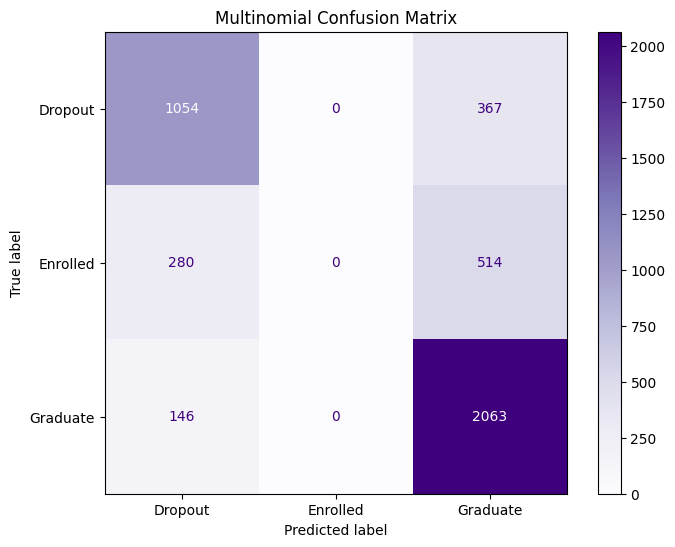

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

model_multi = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model_multi.fit(X_multi, y_multi)

df['multi_preds'] = model_multi.predict(X_multi)

multi_probs = model_multi.predict_proba(X_multi)

conf_matrix_multi = confusion_matrix(y_multi, df['multi_preds'], labels=model_multi.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_multi, display_labels=model_multi.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Purples', ax=ax)
plt.title('Multinomial Confusion Matrix')
plt.show()

The Multinomial Confusion Matrix shows that the model is effective at identifying Graduates and Dropouts, which are the two final states for students. However, the model completely fails to correctly classify Enrolled students, as evidenced by the middle column containing only zeros. This happens because the model never sees Enrolled as the most likely outcome, instead mislabeling these students as either Graduates or Dropouts. Overall, while the model is accurate for clear-cut cases, it cannot distinguish students who are still in the middle of their studies from those who have finished or left.

In [25]:
multi_probs = model_multi.predict_proba(X_multi)

prob_df = pd.DataFrame(multi_probs, columns=model_multi.classes_)

display(prob_df.head())

,Dropout,Enrolled,Graduate
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104


  - The hard classification does not predict every class because the "Enrolled" category never achieves the highest probability in any given row. As seen in the confusion matrix, this results in zero "Enrolled" predictions because the model always finds "Dropout" or "Graduate" to be a more likely outcome.

  - In contrast, the predicted probabilities do predict every class because the model assigns a specific percentage to "Enrolled" for every student. Notably, for many students, the probability for "Enrolled" is consistently the second-highest value. This shows that while the model recognizes these students are in a middle-ground state, it ultimately defaults to choosing the majority categories.

## **Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

### Question 3 - Part 1

In [26]:
import pandas as pd

df = pd.read_csv('cirrhosis.csv')

relevant_cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df_filtered = df[relevant_cols].copy()

display(df_filtered.head())

display(df_filtered.isnull().sum())

print(f"Standard Shape: {df_filtered.shape}")

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


,0
Bilirubin,0
Edema,0
Drug,106
Stage,6
Status,0


Standard Shape: (418, 5)


Since there are 106 missing values for "Drug" and 6 missing for "Stage", those rows will have to be dropped from the dataset. The drugs and stage are highly specific and important to the status so they can't be filled in with a different value.

In [27]:
df_clean = df_filtered.dropna()

print(f"Cleaned shape: {df_clean.shape}")

Cleaned shape: (312, 5)


106 rows were dropped, indicating the 6 rows missing "Stage" were also the ones missing "Drug".

### Question 3 - Part 2

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

df_clean['Status_Binary'] = (df_clean['Status'] == 'D').astype(int)

X = pd.get_dummies(df_clean[['Bilirubin', 'Edema', 'Drug']], drop_first=True)
y = df_clean['Status_Binary']

model = LogisticRegression(penalty=None)
model.fit(X, y)

results = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
display(results)

/tmp/ipykernel_7962/2026820184.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Status_Binary'] = (df_clean['Status'] == 'D').astype(int)


,Feature,Coefficient
0,Bilirubin,0.350381
1,Edema_S,0.578551
2,Edema_Y,2.859322
3,Drug_Placebo,-0.252657


  - **The drug does not improve survival:** With a coefficient of -0.25 for the placebo group, the treatment group actually showed a slightly higher association with mortality, meaning the drug failed to provide a survival benefit.

  - **Higher bilirubin predicts lower survival:** Because the coefficient is positive (0.35), as bilirubin levels increase, the probability of death rises and the survival rate drops.

  - **Survival decreases as edema worsens:** The risk of death increases from the baseline (no edema) to treatable edema (0.58), and spikes drastically with untreatable edema (2.86), which is the strongest predictor of a lower survival rate.

### Question 3 - Part 3

/tmp/ipykernel_7962/1612116409.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Survival_Prob'] = probs[:, 0]


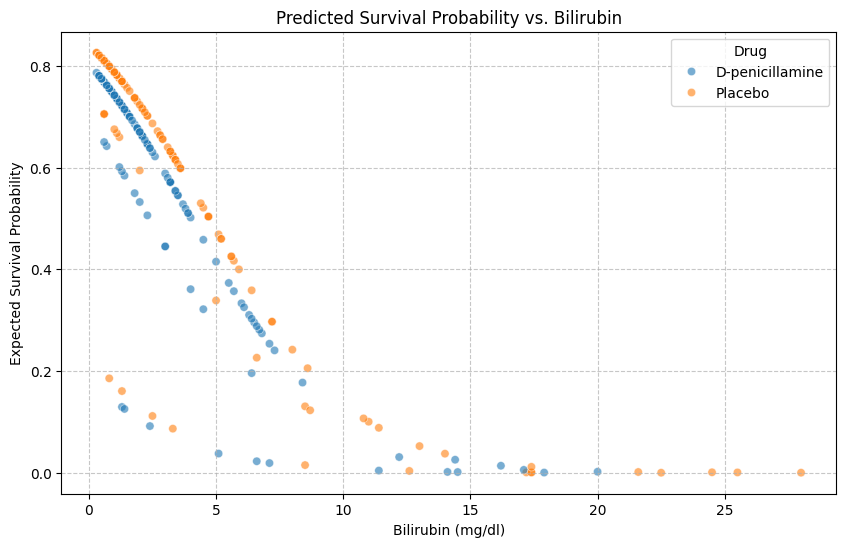

Average Survival (Drug): 0.5886
Average Survival (Placebo): 0.6104
Average Increase for Drug Group: -0.0218


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

probs = model.predict_proba(X)
df_clean['Survival_Prob'] = probs[:, 0]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Bilirubin', y='Survival_Prob', hue='Drug', alpha=0.6)
plt.title('Predicted Survival Probability vs. Bilirubin')
plt.xlabel('Bilirubin (mg/dl)')
plt.ylabel('Expected Survival Probability')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

avg_survival = df_clean.groupby('Drug')['Survival_Prob'].mean()
diff = avg_survival['D-penicillamine'] - avg_survival['Placebo']

print(f"Average Survival (Drug): {avg_survival['D-penicillamine']:.4f}")
print(f"Average Survival (Placebo): {avg_survival['Placebo']:.4f}")
print(f"Average Increase for Drug Group: {diff:.4f}")


  - There are no values of Bilirubin where the drug increases the survival rate. In the scatter plot, the orange dots (Placebo) are consistently higher than the blue dots (D-penicillamine) across the entire x-axis. This shows that at every level of Bilirubin, patients on the placebo have a higher predicted survival probability than those on the drug.

  - Patients who take the drug do not see an increase; they see an average decrease of 0.0218 (or 2.18%) in their survival probability. This is shown by the "Average Increase for Drug Group" value of -0.0218, confirming that the placebo group actually had a higher average survival rate (0.6104) compared to the drug group (0.5886).

### Question 3 - Part 4

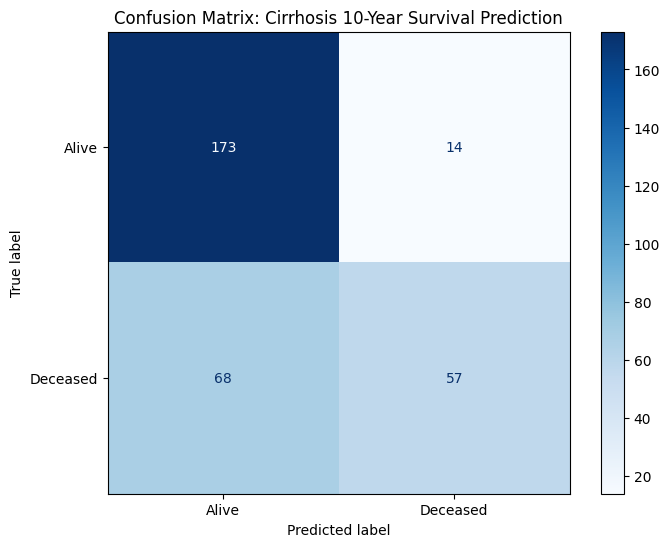

Accuracy: 0.7372


In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alive', 'Deceased'])


fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Cirrhosis 10-Year Survival Prediction')
plt.show()

accuracy = accuracy_score(y, y_pred)
print(f"Accuracy: {accuracy:.4f}")

  - **High Accuracy for Survivors:** The model is very good at identifying those who will stay alive, correctly predicting 173 survivors with only 14 false alarms.

  - **Frequent False Negatives:** The model struggles more with mortality; it incorrectly predicted that 68 deceased patients would survive, which is more than the 57 it correctly identified as deceased.

  - **Overall Accuracy:** The classifier has an overall accuracy of 0.7372 (73.72%), meaning it correctly predicts the 10-year survival outcome for nearly 3 out of 4 patients.

### Question 3 - Part 5

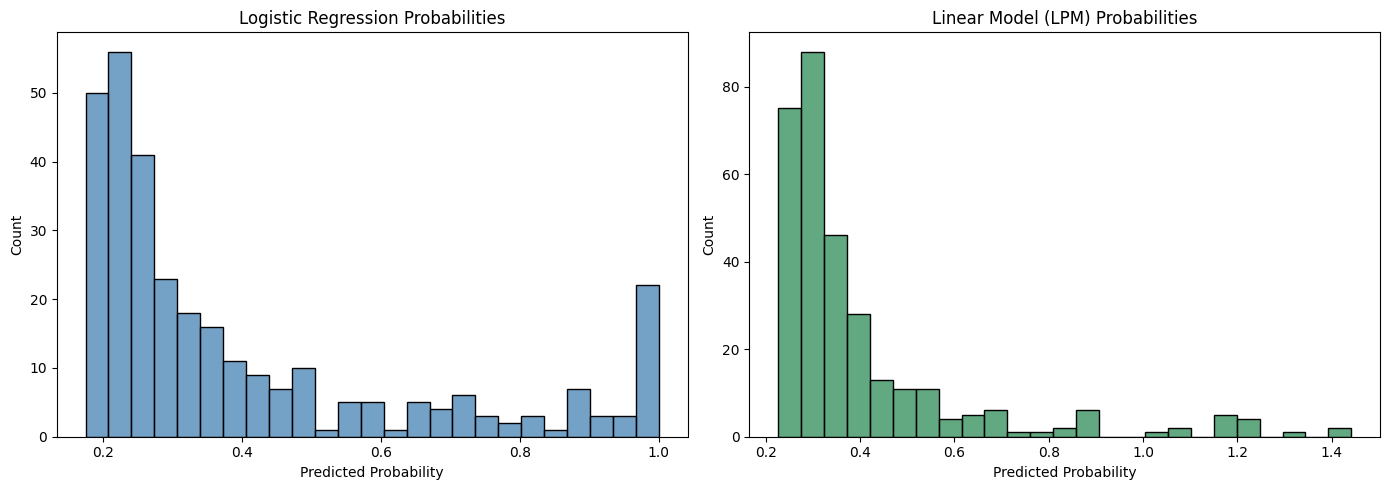

Logistic Regression Accuracy: 0.7372
Linear Model Accuracy: 0.7212


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score

logit = LogisticRegression(penalty=None).fit(X, y)
logit_probs = logit.predict_proba(X)[:, 1]
logit_acc = accuracy_score(y, logit.predict(X))

lpm = LinearRegression().fit(X, y)
lpm_probs = lpm.predict(X)
lpm_acc = accuracy_score(y, (lpm_probs > 0.5).astype(int))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(logit_probs, bins=25, ax=ax1, color='#4682B4')
ax1.set_title('Logistic Regression Probabilities')
ax1.set_xlabel('Predicted Probability')

sns.histplot(lpm_probs, bins=25, ax=ax2, color='#2E8B57')
ax2.set_title('Linear Model (LPM) Probabilities')
ax2.set_xlabel('Predicted Probability')

plt.tight_layout()
plt.show()

print(f"Logistic Regression Accuracy: {logit_acc:.4f}")
print(f"Linear Model Accuracy: {lpm_acc:.4f}")

  - **Accuracy:** The Logistic Regression model has a higher predictive accuracy (0.7372) compared to the Linear Model (0.7212).

  - **Probability Bounds:** The Logistic Regression probabilities are mathematically sound, staying strictly within the 0 to 1 range. The Linear Model (LPM) fails this requirement, predicting "impossible" survival probabilities that exceed 1.4.

  - **Classification Strength:** The Logistic Regression shows a much stronger ability to identify high-risk patients, with a significant "cluster" of predictions near the 1.0 (highest risk) mark. The Linear Model is more hesitant, with fewer predictions reaching the high-risk threshold.

### Question 3 - Part 6

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


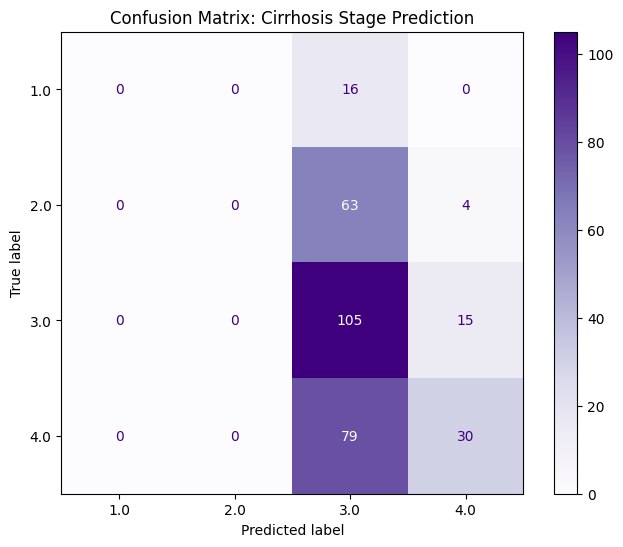

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

model_stage = LogisticRegression(multi_class='multinomial', max_iter=1000)

model_stage.fit(X[['Edema_S', 'Edema_Y', 'Bilirubin']], df_clean['Stage'])

stage_preds = model_stage.predict(X[['Edema_S', 'Edema_Y', 'Bilirubin']])

stage_probs = model_stage.predict_proba(X[['Edema_S', 'Edema_Y', 'Bilirubin']])

disp = ConfusionMatrixDisplay(confusion_matrix=cm_stage, display_labels=model_stage.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Purples', ax=ax)
plt.title('Confusion Matrix: Cirrhosis Stage Prediction')
plt.show()

  - **Failure to Predict All Classes:** The hard classification fails to predict every class, as there are zero predictions for Stage 1.0 and Stage 2.0.

  - **Heavy Bias Toward Stage 3:** The model is heavily biased toward predicting Stage 3.0, assigning this label to the vast majority of patients regardless of their true stage.

  - **Limited Success with Advanced Stages:** The model only correctly identifies 105 patients in Stage 3.0 and 30 patients in Stage 4.0, while misclassifying 79 Stage 4.0 patients as Stage 3.0.

In [41]:
predicted_classes = np.unique(stage_preds)
all_classes = model_stage.classes_

probs_df = pd.DataFrame(stage_probs, columns=[f"Stage {c}" for c in model_stage.classes_])

display(probs_df.head())

,Stage 1.0,Stage 2.0,Stage 3.0,Stage 4.0
0,0.000013,0.032535,0.143611,0.823841
1,0.072394,0.251555,0.397520,0.278531
2,0.029263,0.181531,0.395694,0.393512
3,0.023272,0.176777,0.397217,0.402734
4,0.020204,0.224965,0.423342,0.331488


  - **Hard Classification:** The hard classification does not predict every class. As shown in the confusion matrix, there are zero instances where the model predicted Stage 1.0 or Stage 2.0. The model only generated hard predictions for Stage 3.0 and Stage 4.0.

  - **Predicted Probabilities:** The predicted probabilities do predict every class. Even when the model fails to choose a specific stage as the "winner" for a hard prediction, it still calculates a non-zero numerical probability for every possible outcome.

## **Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

### Question 4 - Part 1

For the linear model $\hat{y} = b_0 + \sum_{k=1}^{K} b_k x_k$:

*   **Derivative with respect to $x_k$**: The derivative is simply the coefficient **$b_k$**.
*   **1-Unit Change**: For every 1-unit increase in the feature $x_k$, the prediction $\hat{y}$ changes by exactly **$b_k$**. This relationship is constant; the effect of $x_k$ does not depend on the values of any other variables.

### Question 4 - Part 2

For the logistic model $\hat{p_i} = \frac{e^{b \cdot x}}{1 + e^{b \cdot x}}$:

*   **Derivative with respect to $x_k$**: Using the chain rule provided in the hint, the derivative is:
    $$\frac{\partial \hat{p_i}}{\partial x_k} = \hat{p_i}(1 - \hat{p_i})b_k$$
*   **Changing $x$**: Yes, the answer changes as $x$ changes. Unlike the linear model, the effect of a feature on the probability $\hat{p_i}$ is non-linear and depends on the current value of $\hat{p_i}$.
*   **Rule of Thumb (Divide by 4)**: The coefficient $b_k$ is a good estimate of the maximum effect on prediction (when divided by 4) when **$\hat{p}$ is roughly 0.5**. This is because the term $\hat{p_i}(1 - \hat{p_i})$ reaches its maximum value of $0.25$ at $\hat{p} = 0.5$.

### Question 4- Part 3

Alternatively, we transform the model into the logit form: $\log\left(\frac{\hat{p}}{1 - \hat{p}}\right) = b \cdot x$.

*   **One Unit Change**: In this transformed state, the relationship is linear. A one-unit change in $x_k$ affects the **log odds ratio** by exactly the value of the coefficient **$b_k$**.
*   **Summary**: While $b_k$ has a complex effect on raw probability, it has a simple, additive effect on the log odds of the outcome.